# Running Palace Simulations

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a spiral inductor with Metal1 guard ring.

**Requirements:**
- IHP PDK: `uv pip install ihp-gdsfactory`
- gsim with Palace backend


### Build inductor + guard ring

**Known PDK limitation:** `gf.components.inductor` accepts a `turns` parameter but does not use it in geometry construction. The spiral is always single-turn regardless of the value passed."""


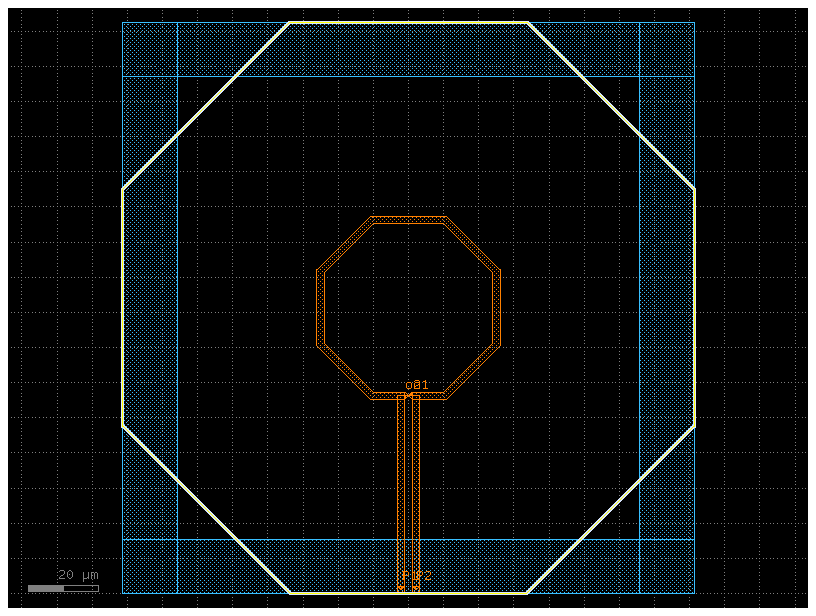

In [1]:
import gdsfactory as gf
from ihp import PDK

PDK.activate()

c = gf.components.inductor(
    width=2,
    space=2.1,
    diameter=50,
    turns=1,
    layer_metal="TopMetal2drawing",
    layer_inductor="INDdrawing",
    layer_metal_pin="TopMetal2drawing",
    layers_no_fill=("NoMetFillerdrawing",),
).copy()

# Define guard ring dimensions based on the inductor's bounding box
bbox = c.bbox()
xmin, ymin = bbox.left, bbox.bottom
xmax, ymax = bbox.right, bbox.top

margin_outer = 0.0
margin_inner = -15.0

xlo, xro = xmin - margin_outer, xmax + margin_outer
ybo, yto = ymin - margin_outer, ymax + margin_outer
xli, xri = xmin - margin_inner, xmax + margin_inner
ybi, yti = ymin - margin_inner, ymax + margin_inner

w_v = xli - xlo  # Width vertical walls
h_h = yto - yti  # Height horizontal walls
over = 0.5  # Overlap for Gmsh to fuse the pieces

# Left wall
c.add_ref(
    gf.components.rectangle(
        size=(w_v + over, yto - ybo), layer="Metal1drawing", centered=True
    )
).move((xlo + w_v / 2 + over / 2, (yto + ybo) / 2))
# Right wall
c.add_ref(
    gf.components.rectangle(
        size=(w_v + over, yto - ybo), layer="Metal1drawing", centered=True
    )
).move((xro - w_v / 2 - over / 2, (yto + ybo) / 2))
# Top wall
c.add_ref(
    gf.components.rectangle(
        size=(xro - xlo, h_h + over), layer="Metal1drawing", centered=True
    )
).move(((xro + xlo) / 2, yto - h_h / 2 - over / 2))
# Bottom wall
c.add_ref(
    gf.components.rectangle(
        size=(xro - xlo, h_h + over), layer="Metal1drawing", centered=True
    )
).move(((xro + xlo) / 2, ybo + h_h / 2 + over / 2))

cc = c.copy()

c.draw_ports()
c.plot()

### Configure and run simulation with DrivenSim

In [2]:
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-inductor-guardring")

# Set the component geometry
sim.set_geometry(cc)

# Configure layer stack from active PDK
sim.set_stack(substrate_thickness=180.0, air_above=200.0, include_substrate=True)

# Configure ports
sim.add_port(
    "P1", from_layer="metal1", to_layer="topmetal2", geometry="via", excited=True
)
sim.add_port(
    "P2", from_layer="metal1", to_layer="topmetal2", geometry="via", excited=True
)

# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=10e9, fmax=200e9, num_points=50)

# Validate configuration
print(sim.validate_config())

Validation: PASSED


In [3]:
# Generate mesh (presets: "coarse", "default", "fine")
sim.mesh(preset="default", margin=50, refined_mesh_size=1.5)

Small conductor feature detected (2.100 um) may be under-resolved by refined_mesh_size=5.000 um. Pass auto_size=True to scale the mesh down.


Mesh Summary
Dimensions: 262.6 x 262.6 x 396.3 µm
Nodes:      10,221
Elements:   73,964
Tetrahedra: 52,098
Edge length: 0.40 - 185.69 µm
Quality:    0.538 (min: 0.000)
SICN:       0.578 (all valid)
----------------------------------------
Volumes (4):
  - silicon [1]
  - SiO2 [2]
  - passive [3]
  - air [4]
Surfaces (13):
  - metal1_xy [5]
  - metal1_z [6]
  - topmetal2_xy [7]
  - topmetal2_z [8]
  - P1 [9]
  - P2 [10]
  - silicon__None [11]
  - SiO2__silicon [12]
  - SiO2__None [13]
  - SiO2__passive [14]
  - passive__None [15]
  - air__passive [16]
  - air__None [17]
----------------------------------------
Mesh:   palace-sim-inductor-guardring/palace.msh

In [4]:
sim.plot_mesh(show_groups=["metal", "P"])

Widget(value='<iframe src="http://localhost:35979/index.html?ui=P_0x727d7019c410_0&reconnect=auto" class="pyvi…

### Run simulation on cloud

In [13]:
# Run simulation on GDSFactory+ cloud
results = sim.run()

  palace-ab3528dd  completed  2m 42s
Extracting results.tar.gz...
Downloaded 11 files to /home/delfina/projects/gsim/nbs/IHP_components/sim-data-palace-ab3528dd


In [14]:
results.plot_interactive()

Port mapping: Port 1: P1, Port 2: P2


In [15]:
results.plot_interactive(phase=True)

Port mapping: Port 1: P1, Port 2: P2
